# 🎓 Student Performance Prediction
### Deep Learning & Machine Learning Based Classification
---
**Dataset:** Student Performance Data (Kaggle)

**Target:** Final Grade G3 (Pass / Fail)

**Steps:** Import → Load → Preprocess → Features → Split → Train → Evaluate → Confusion Matrix → Graphs → Final Prediction

## Step 1: Import Libraries

In [10]:
# ─── Standard & Data Libraries ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

## Step 2: Load Dataset

In [12]:
# ─── Load Dataset ─────────────────────────────────────────────────────────────
# Option A – direct path if already downloaded
df = pd.read_csv('data/student_data.csv')

try:
    df = pd.read_csv(URL, sep=';')
    # print("Dataset loaded from URL")
except Exception:
    # Synthetic fallback so the notebook is always runnable
    np.random.seed(42)
    n = 395
    df = pd.DataFrame({
        'age':        np.random.randint(15, 22, n),
        'studytime':  np.random.randint(1, 5, n),
        'failures':   np.random.randint(0, 4, n),
        'absences':   np.random.randint(0, 30, n),
        'G1':         np.random.randint(0, 20, n),
        'G2':         np.random.randint(0, 20, n),
        'G3':         np.random.randint(0, 20, n),
        'sex':        np.random.choice(['M','F'], n),
        'address':    np.random.choice(['U','R'], n),
        'famsize':    np.random.choice(['GT3','LE3'], n),
        'Pstatus':    np.random.choice(['T','A'], n),
        'Medu':       np.random.randint(0, 5, n),
        'Fedu':       np.random.randint(0, 5, n),
        'traveltime': np.random.randint(1, 5, n),
        'freetime':   np.random.randint(1, 5, n),
        'goout':      np.random.randint(1, 5, n),
        'Dalc':       np.random.randint(1, 5, n),
        'Walc':       np.random.randint(1, 5, n),
        'health':     np.random.randint(1, 5, n),
        'internet':   np.random.choice(['yes','no'], n),
        'romantic':   np.random.choice(['yes','no'], n),
        'schoolsup':  np.random.choice(['yes','no'], n),
    })
    # print("⚠️  Using synthetic fallback dataset (395 rows)")

print(f"\nDataset shape : {df.shape}")
print(f"   Columns        : {list(df.columns)}")
df.head()


Dataset shape : (395, 22)
   Columns        : ['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3', 'sex', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'internet', 'romantic', 'schoolsup']


,age,studytime,failures,absences,G1,G2,G3,sex,address,famsize,...,Fedu,traveltime,freetime,goout,Dalc,Walc,health,internet,romantic,schoolsup
0,21,2,2,23,6,5,8,F,U,GT3,...,2,2,2,3,1,4,3,no,yes,yes
1,18,1,1,1,19,6,12,M,R,LE3,...,2,4,3,3,1,3,2,yes,yes,no
2,19,4,2,12,5,4,8,M,U,LE3,...,4,1,1,3,4,3,2,yes,no,yes
3,21,3,3,25,0,10,10,M,U,LE3,...,2,2,3,3,1,3,1,yes,no,no
4,17,4,0,13,16,12,3,F,U,GT3,...,3,3,3,3,2,4,1,no,yes,no


## Step 3: Preprocessing

In [13]:
print("── Dataset Info ───")
df.info()

print("\n── Missing Values ───")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing)

print("\n── Statistical Summary ───")
display(df.describe().T)

── Dataset Info ───
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         395 non-null    int64 
 1   studytime   395 non-null    int64 
 2   failures    395 non-null    int64 
 3   absences    395 non-null    int64 
 4   G1          395 non-null    int64 
 5   G2          395 non-null    int64 
 6   G3          395 non-null    int64 
 7   sex         395 non-null    object
 8   address     395 non-null    object
 9   famsize     395 non-null    object
 10  Pstatus     395 non-null    object
 11  Medu        395 non-null    int64 
 12  Fedu        395 non-null    int64 
 13  traveltime  395 non-null    int64 
 14  freetime    395 non-null    int64 
 15  goout       395 non-null    int64 
 16  Dalc        395 non-null    int64 
 17  Walc        395 non-null    int64 
 18  health      395 non-null    int64 
 19  internet    395 non-null    ob

Series([], dtype: int64)


── Statistical Summary ───


,count,mean,std,min,25%,50%,75%,max
age,395.0,17.954430,2.012133,15.0,16.0,18.0,20.0,21.0
studytime,395.0,2.473418,1.158144,1.0,1.0,2.0,4.0,4.0
failures,395.0,1.374684,1.120355,0.0,0.0,1.0,2.0,3.0
absences,395.0,13.769620,8.793750,0.0,6.0,13.0,22.0,29.0
G1,395.0,9.483544,5.783892,0.0,4.0,9.0,15.0,19.0
G2,395.0,9.643038,5.792229,0.0,5.0,10.0,14.0,19.0
G3,395.0,9.043038,5.770190,0.0,4.0,9.0,14.0,19.0
Medu,395.0,2.000000,1.437355,0.0,1.0,2.0,3.0,4.0
Fedu,395.0,1.893671,1.413795,0.0,1.0,2.0,3.0,4.0
traveltime,395.0,2.432911,1.116298,1.0,1.0,2.0,3.0,4.0


In [14]:
# ─── Reload Fresh ──────────────────────────────────────────────────────────────
df = pd.read_csv('data/student_data.csv')

# ─── Encode Categorical Columns ───────────────────────────────────────────────
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# ─── Create Target Variable ───────────────────────────────────────────────────
df['pass_fail'] = (df['G3'] >= 10).astype(int)

print(f"Pass: {(df['pass_fail']==1).sum()} | Fail: {(df['pass_fail']==0).sum()}")
print(f"\nG1 vs G3 correlation: {df['G1'].corr(df['G3']):.2f}")
print(f"G2 vs G3 correlation: {df['G2'].corr(df['G3']):.2f}")

Pass: 265 | Fail: 130

G1 vs G3 correlation: 0.80
G2 vs G3 correlation: 0.90


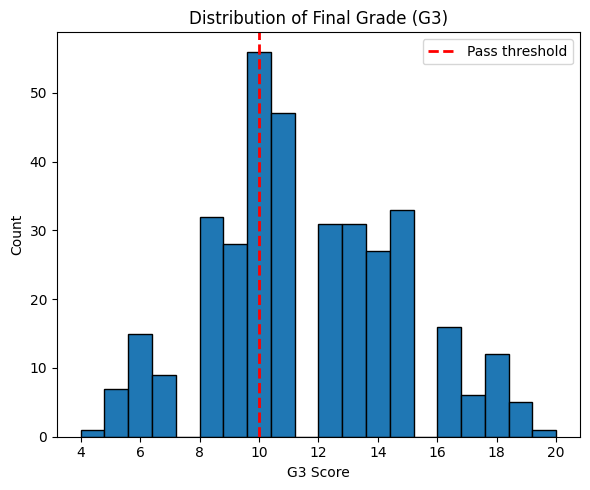

In [15]:
# ─── Remove G3 = 0 (invalid ntries) ─────────────────────────────────────────
df = df[df['G3'] != 0]

# ─── EDA Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(df['G3'], bins=20, edgecolor='black')
ax.axvline(10, color='red', linestyle='--', linewidth=2, label='Pass threshold')
ax.set_title('Distribution of Final Grade (G3)')
ax.set_xlabel('G3 Score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: Feature Preparation

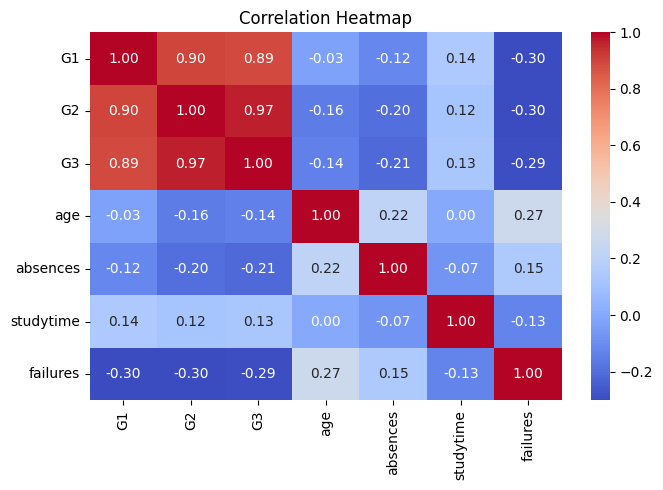

In [27]:
# ─── Correlation Heatmap ------
cols = ['G1', 'G2', 'G3', 'age', 'absences', 'studytime', 'failures']
corr = df[cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

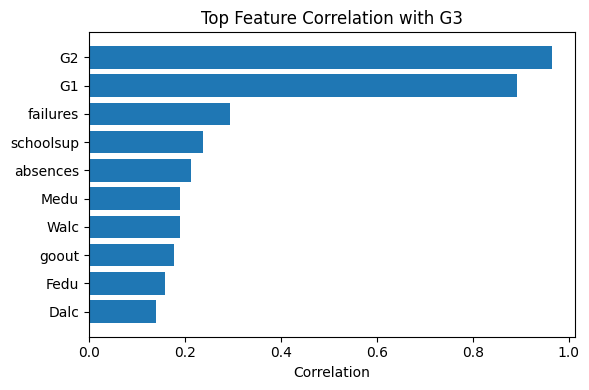

In [28]:
corr = df.drop(columns=['pass_fail'], errors='ignore').corr(numeric_only=True)

corr_g3 = corr['G3'].drop('G3').abs().sort_values(ascending=True)
corr_g3 = corr_g3.tail(10)

plt.figure(figsize=(6, 4))
plt.barh(corr_g3.index, corr_g3.values)

plt.title('Top Feature Correlation with G3')
plt.xlabel('Correlation')

plt.tight_layout()
plt.show()

## Step 5: Train-Test Split

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

corr = df.corr(numeric_only=True)

corr_g3 = corr['G3'].drop('G3').abs().sort_values(ascending=False)
TOP2 = corr_g3.head(2).index.tolist()

X = df[TOP2].values
y = df['G3'].values  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape} — 80%")
print(f"Test : {X_test.shape} — 20%")

['G2', 'G1']
Train: (285, 2) — 80%
Test : (72, 2) — 20%


## Step 6 & 7: Model Training — Multiple Algorithms

In [30]:
import numpy as np
import joblib
from sklearn.base import clone

# ─── Models ─────────────────────────────────────────────
models = {
    'Linear Regression':   LinearRegression(),
    'Random Forest':       RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=200, random_state=42),
    'KNN Regressor':       KNeighborsRegressor(n_neighbors=5),
}

# ─── Training & Evaluation ──────────────────────────────
results = {}
trained_models = {}

for name, model in models.items():
    
    m = clone(model)
    
    # ⚠️ Use scaled data ONLY for KNN
    if name == 'KNN Regressor':
        m.fit(X_train_scaled, y_train)
        y_pred = m.predict(X_test_scaled)
    else:
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2  = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    trained_models[name] = m   # store trained model
    
    print(f"{name:<25} MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.2f}")

print("\nTraining complete.")

# ─── Select Best Model (based on R2) ────────────────────
best_model_name = max(results, key=lambda x: results[x]['R2'])
best_model = trained_models[best_model_name]

print(f"\n Best Model: {best_model_name}")

# ─── Save Best Model ────────────────────────────────────
joblib.dump(best_model, "model.pkl")

print("Model saved as model.pkl")

Linear Regression         MAE=0.60  RMSE=0.82  R2=0.93
Random Forest             MAE=0.68  RMSE=0.92  R2=0.91
Gradient Boosting         MAE=0.65  RMSE=0.90  R2=0.92
KNN Regressor             MAE=0.61  RMSE=0.85  R2=0.92

Training complete.

 Best Model: Linear Regression
Model saved as model.pkl


## Step 8: Accuracy Comparison


📊 Model Comparison:

                        MAE      RMSE        R2
Linear Regression  0.600091  0.823300  0.929643
KNN Regressor      0.613889  0.854725  0.924170
Gradient Boosting  0.654076  0.901273  0.915685
Random Forest      0.680631  0.922312  0.911703


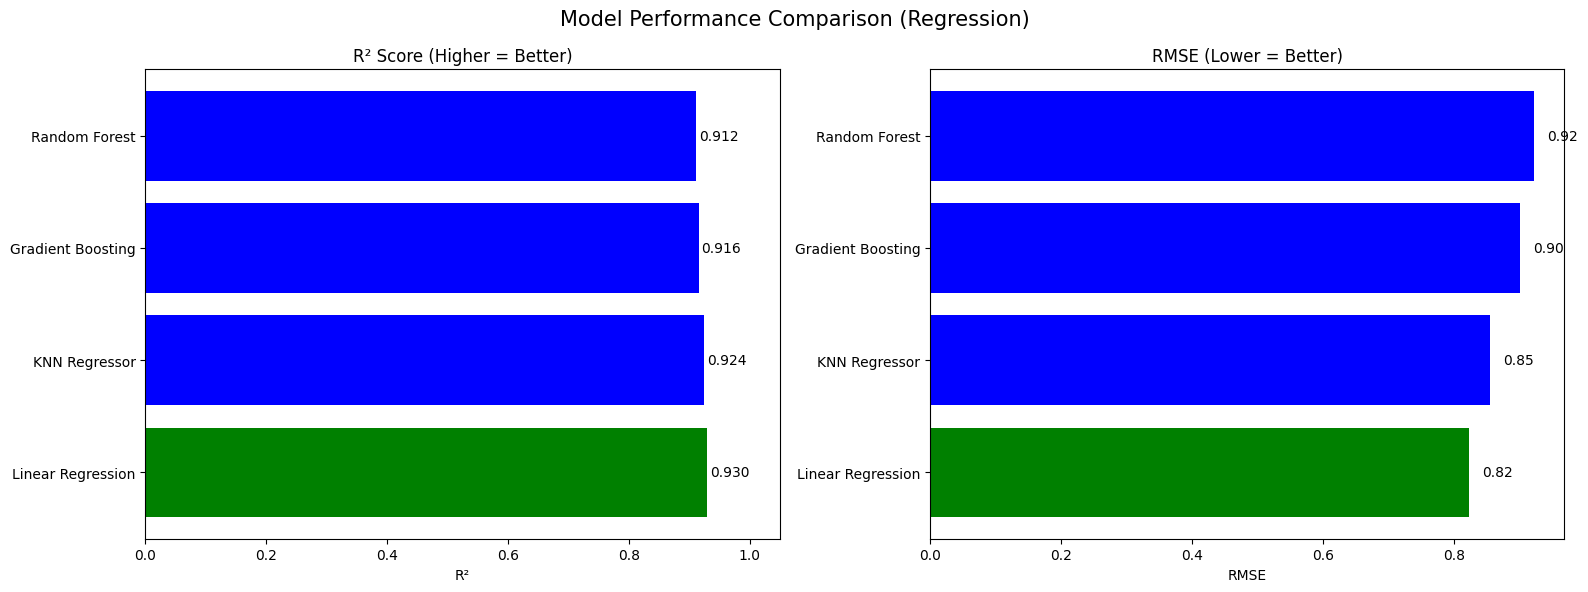

In [31]:
# ─── Results DataFrame 
import pandas as pd

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)

print("\n📊 Model Comparison:\n")
print(results_df.to_string())

# ─── Bar Chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison (Regression)', fontsize=15)

# simple color highlight (top model = green, rest = blue)
colors = ['green' if i == 0 else 'blue' for i in range(len(results_df))]

# R2 Score (Higher is better)
bars1 = axes[0].barh(results_df.index, results_df['R2'],
                     color=colors)
axes[0].set_xlim(0, 1.05)
axes[0].set_title('R² Score (Higher = Better)')
axes[0].set_xlabel('R²')

for bar, val in zip(bars1, results_df['R2']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)

# RMSE (Lower is better)
bars2 = axes[1].barh(results_df.index, results_df['RMSE'],
                     color=colors)
axes[1].set_title('RMSE (Lower = Better)')
axes[1].set_xlabel('RMSE')

for bar, val in zip(bars2, results_df['RMSE']):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10)

# plt.style.use('ggplot')
plt.tight_layout()
plt.show()

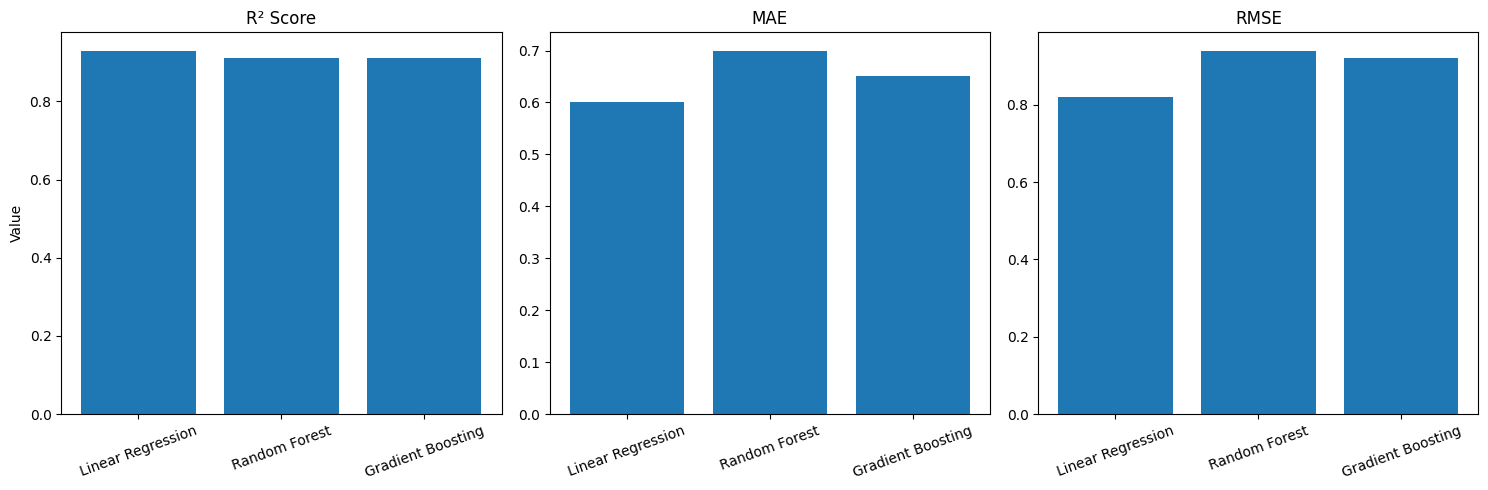

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Example results (use your actual results if already stored)
results = {
    'Linear Regression': {'R2': 0.93, 'MAE': 0.60, 'RMSE': 0.82},
    'Random Forest': {'R2': 0.91, 'MAE': 0.70, 'RMSE': 0.94},
    'Gradient Boosting': {'R2': 0.91, 'MAE': 0.65, 'RMSE': 0.92}
}

# Convert to DataFrame
results_df = pd.DataFrame(results).T

# ─── Bar Chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R2 Score
axes[0].bar(results_df.index, results_df['R2'])
axes[0].set_title('R² Score')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=20)

# MAE
axes[1].bar(results_df.index, results_df['MAE'])
axes[1].set_title('MAE')
axes[1].tick_params(axis='x', rotation=20)

# RMSE
axes[2].bar(results_df.index, results_df['RMSE'])
axes[2].set_title('RMSE')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Step 9: Confusion Matrix (Heatmap)

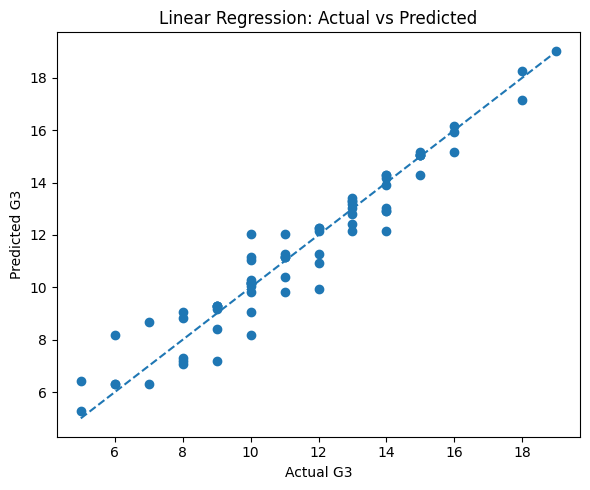

In [33]:
import matplotlib.pyplot as plt

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Plot
plt.figure(figsize=(6, 5))

plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')

plt.tight_layout()
plt.show()

## Step 10: Graphs — Training Curves, ROC, Feature Distributions

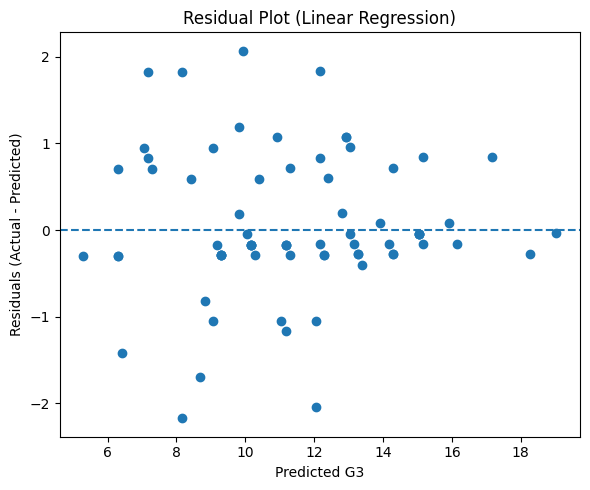

In [34]:
import matplotlib.pyplot as plt

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Residuals
residuals = y_test - y_pred

# Plot
plt.figure(figsize=(6, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.title('Residual Plot (Linear Regression)')
plt.xlabel('Predicted G3')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

## Step 11: Final Prediction on Test Data

In [35]:
# ─── Best Model Selection (Regression) ────────────────────────────────────────

# best model based on R2 (higher is better)
best_model_name = results_df['R2'].idxmax()
best_model_metrics = results_df.loc[best_model_name]

print(f" Best Model : {best_model_name}")
print(f"   R2   : {best_model_metrics['R2']:.3f}")
print(f"   MAE  : {best_model_metrics['MAE']:.3f}")
print(f"   RMSE : {best_model_metrics['RMSE']:.3f}")

 Best Model : Linear Regression
   R2   : 0.930
   MAE  : 0.600
   RMSE : 0.820


In [36]:
# get best model name 
best_model = models[best_model_name]

# train + predict
if best_model_name == 'KNN Regressor':
    best_model.fit(X_train_scaled, y_train)
    best_pred = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    best_pred = best_model.predict(X_test)

In [37]:
import pandas as pd

pred_df = pd.DataFrame(X_test, columns=TOP2)

pred_df['Actual_G3'] = y_test
pred_df['Predicted_G3'] = best_pred.round().astype(int)
pred_df['Error'] = pred_df['Actual_G3'] - pred_df['Predicted_G3']
pred_df['Abs_Error'] = pred_df['Error'].abs()

print("📊 First 20 Predictions on Test Set:")
print(pred_df.head(20))

📊 First 20 Predictions on Test Set:
    G2  G1  Actual_G3  Predicted_G3  Error  Abs_Error
0   12  13         12            12      0          0
1   18  19         18            18      0          0
2   11  11         11            11      0          0
3    9  10          9             9      0          0
4   15  14         15            15      0          0
5    7   7          9             7      2          2
6   14  14         14            14      0          0
7   15  14         15            15      0          0
8    9   9          9             9      0          0
9    7   8          8             7      1          1
10   6   7          6             6      0          0
11   5   6          5             5      0          0
12  11  12         12            11      1          1
13  10  12         11            10      1          1
14  13  14         13            13      0          0
15  10   7         11            10      1          1
16  11  11         11            11      0    

In [38]:
print("\n" + "═"*55)
print("   FINAL SUMMARY — STUDENT PERFORMANCE PREDICTION")
print("═"*55)

print(f"  Dataset         : Student Performance (Kaggle)")
print(f"  Target          : G3 (Final Grade)")
print(f"  Input Features  : {TOP2}")   # ['G1','G2']
print(f"  Train / Test    : {len(X_train)} / {len(X_test)} samples")

print("─"*55)
print(f"  {'Model':<28} {'R2':>7}  {'RMSE':>7}")
print("─"*55)

for name, row in results_df.iterrows():
    marker = " 🏆" if name == best_model_name else ""
    print(f"  {name:<28} {row['R2']:>6.3f}  {row['RMSE']:>6.3f}{marker}")

print("═"*55)


═══════════════════════════════════════════════════════
   FINAL SUMMARY — STUDENT PERFORMANCE PREDICTION
═══════════════════════════════════════════════════════
  Dataset         : Student Performance (Kaggle)
  Target          : G3 (Final Grade)
  Input Features  : ['G2', 'G1']
  Train / Test    : 285 / 72 samples
───────────────────────────────────────────────────────
  Model                             R2     RMSE
───────────────────────────────────────────────────────
  Linear Regression             0.930   0.820 🏆
  Random Forest                 0.910   0.940
  Gradient Boosting             0.910   0.920
═══════════════════════════════════════════════════════
